# Resume NER v8 — Baseline vs LoRA Comparison
## المقارنة: BERT بدون LoRA  vs  BERT + LoRA
| | Baseline | LoRA |
|---|---|---|
| **Trainable params** | كل الـ params (~110M) | ~1-3M بس |
| **Memory** | أعلى | أقل بكتير |
| **Speed** | أبطأ | أسرع |
| **Performance** | غالباً أعلى F1 | قريب جداً أو أعلى |

### الـ Notebook ده بيعمل إيه؟
1. ✅ يشارك نفس البيانات والـ split بين الاتنين (fair comparison)
2. ✅ يدرّب **Baseline BERT** (full fine-tune)
3. ✅ يدرّب **BERT + LoRA**
4. ✅ يقارن F1 / Precision / Recall / Training time / Params
5. ✅ يرسم comparison chart واضح


In [ ]:
# Cell 1: Install Dependencies
!pip install transformers datasets evaluate seqeval peft accelerate pypdf2 matplotlib -q
!pip install torchao==0.16.0 -q
print("✅ Dependencies installed")

✅ Dependencies installed


In [ ]:
# Cell 2: Imports
import json, re, os, copy, random, time
from collections import Counter, deque
import numpy as np
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, DataCollatorForTokenClassification, Trainer
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
from datasets import Dataset
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')


In [ ]:
# Cell 3: Shared Configuration (same for both runs)
MODEL_NAME   = 'dslim/bert-base-NER'
DATA_PATH    = 'Entity Recognition in Resumes.json'
BASE_OUT     = './resume_ner_v8_baseline'
LORA_OUT     = './resume_ner_v8_lora'
os.makedirs(BASE_OUT, exist_ok=True)
os.makedirs(LORA_OUT, exist_ok=True)

# ── Training ──
MAX_LEN      = 256
BATCH_SIZE   = 16
GRAD_ACCUM   = 2
EPOCHS       = 50
LR_BASELINE  = 2e-5   # Full fine-tune: LR أصغر عشان ما يـoverfitش
LR_LORA      = 2e-4   # LoRA: LR أكبر لأن params أقل
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06

# ── LoRA ──
LORA_R       = 32
LORA_ALPHA   = 64
LORA_DROPOUT = 0.1
LORA_MODULES = ['query', 'key', 'value', 'dense']

# ── Data ──
WEIGHT_EXP   = 0.40
MAX_WEIGHT   = 5.0
LABEL_SMOOTH = 0.05
N_SYNTHETIC  = 400
PATIENCE     = 3
SMOOTH_WIN   = 2
TTA_RUNS     = 3
INF_CONF     = 0.45
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
TARGET_ENTITIES = {'Name', 'Email Address', 'Skills'}

print('✅ Config loaded')
print(f'   LR Baseline: {LR_BASELINE} | LR LoRA: {LR_LORA}')
print(f'   Epochs: {EPOCHS} | Patience: {PATIENCE}')


✅ Config loaded
   LR Baseline: 2e-05 | LR LoRA: 0.0002
   Epochs: 50 | Patience: 3


In [ ]:
# Cell 4: Skills Pool
SKILLS_POOL = [
    'Python','Java','JavaScript','TypeScript','C++','C#','C','R','Go','Rust',
    'Kotlin','Swift','PHP','Ruby','Scala','MATLAB','Perl','Bash','Shell',
    'React','Angular','Vue.js','Node.js','Express.js','Django','Flask','FastAPI',
    'Spring Boot','Laravel','HTML','CSS','Bootstrap','Tailwind',
    'TensorFlow','PyTorch','Keras','Scikit-learn','XGBoost','LightGBM',
    'Pandas','NumPy','SciPy','Matplotlib','Seaborn','Plotly',
    'Machine Learning','Deep Learning','NLP','Computer Vision',
    'Feature Engineering','Model Deployment','MLOps',
    'SQL','MySQL','PostgreSQL','SQLite','MongoDB','Redis','Cassandra',
    'Oracle','SQL Server','Elasticsearch',
    'Power BI','Tableau','Looker','Excel','Google Analytics','Qlik',
    'AWS','Azure','GCP','Docker','Kubernetes','Terraform','Ansible',
    'CI/CD','Jenkins','GitHub Actions','Linux','Git','GitHub',
    'LangChain','OpenAI API','Hugging Face','Transformers','BERT','GPT',
    'Fine-tuning','RAG','Vector DB','Pinecone','FAISS',
    'REST API','GraphQL','Microservices','Agile','Scrum','Jira','Confluence',
]
ALL_SKILLS_FLAT = list(dict.fromkeys(SKILLS_POOL))
print(f'✅ Skills pool: {len(ALL_SKILLS_FLAT)} skills')


✅ Skills pool: 99 skills


In [ ]:
# Cell 5: Load Data + Build Label Schema
data = []
with open(DATA_PATH, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line: data.append(json.loads(line))
print(f'Total resumes: {len(data)}')

ENTITIES   = sorted(TARGET_ENTITIES)
ALL_LABELS = ['O'] + [f'{p}-{e}' for e in ENTITIES for p in ('B', 'I')]
label2id   = {l: i for i, l in enumerate(ALL_LABELS)}
id2label   = {i: l for i, l in enumerate(ALL_LABELS)}
N_LABELS   = len(ALL_LABELS)
print(f'Entities: {ENTITIES}')
print(f'Labels ({N_LABELS}): {ALL_LABELS}')


Total resumes: 220
Entities: ['Email Address', 'Name', 'Skills']
Labels (7): ['O', 'B-Email Address', 'I-Email Address', 'B-Name', 'I-Name', 'B-Skills', 'I-Skills']


In [ ]:
# Cell 6: Parser
def clean_text(t):
    if not isinstance(t, str): return ''
    return t.encode('utf-8', errors='ignore').decode('utf-8')

def parse_resume(content, annotations):
    content  = clean_text(content)
    char_ent = {}
    for ann in (annotations or []):
        if not ann or not ann.get('label') or not ann.get('points'): continue
        lbl = ann['label'][0]
        if lbl not in TARGET_ENTITIES: continue
        for pt in ann['points']:
            for c in range(pt.get('start', 0), pt.get('end', 0) + 1):
                char_ent[c] = lbl
    words, ws, we = [], [], []
    for m in re.finditer(r'\S+', content):
        words.append(m.group()); ws.append(m.start()); we.append(m.end())
    if not words: return None
    bio, prev = [], None
    for s, e in zip(ws, we):
        hits = [char_ent[c] for c in range(s, e) if c in char_ent]
        if hits:
            ent = Counter(hits).most_common(1)[0][0]
            bio.append(label2id[f"{'I' if ent==prev else 'B'}-{ent}"])
            prev = ent
        else:
            bio.append(label2id['O']); prev = None
    return [clean_text(w) for w in words if clean_text(w)], bio

all_tokens, all_tags = [], []
for row in data:
    r = parse_resume(row.get('content',''), row.get('annotation',[]))
    if r and len(r[0]) == len(r[1]):
        all_tokens.append(r[0]); all_tags.append(r[1])
print(f'✅ Parsed: {len(all_tokens)} resumes')


✅ Parsed: 220 resumes


In [ ]:
# Cell 7: Train/Val/Test Split (SHARED — same for both runs)
from sklearn.model_selection import train_test_split

train_tokens, temp_tokens, train_tags, temp_tags = train_test_split(
    all_tokens, all_tags, test_size=VAL_RATIO + TEST_RATIO, random_state=42
)
val_ratio_adj = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_tokens, test_tokens, val_tags, test_tags = train_test_split(
    temp_tokens, temp_tags, test_size=1 - val_ratio_adj, random_state=42
)
print(f'✅ Split — Train: {len(train_tokens)} | Val: {len(val_tokens)} | Test: {len(test_tokens)}')
print('   ⚠️  نفس الـ split لازم يتستخدم للاتنين عشان المقارنة تبقى fair')


✅ Split — Train: 154 | Val: 33 | Test: 33
   ⚠️  نفس الـ split لازم يتستخدم للاتنين عشان المقارنة تبقى fair


In [ ]:
# Cell 8: Synthetic Data (SHARED)
NAMES = [
    'Ahmed Ali','Sara Mohamed','Omar Hassan','Fatima Khalid',
    'Youssef Ibrahim','Nour Ahmed','Aditi Sharma','Rahul Kumar',
    'John Smith','Emily Johnson','Michael Brown','Priya Patel',
    'Khaled Mansour','Laila Hassan','Mostafa Samir','Rana Tarek',
    'David Wilson','Sophia Martinez','Mohamed Hammad','Aisha Diallo',
    'Amr Youssef','Dina Farouk','Karim Salah','Mona Gamal',
]

def make_synthetic():
    name  = random.choice(NAMES)
    parts = name.lower().split()
    email = f"{parts[0]}.{parts[-1]}@{random.choice(['gmail','yahoo','outlook'])}.com"
    skills = random.sample(SKILLS_POOL, random.randint(5, 9))
    sk_lines = '\n'.join(f'- {s}' for s in skills)
    text = f"{name}\n{email}\n\nSKILLS\n{sk_lines}"
    words = text.split()
    bio   = [label2id['O']] * len(words)
    def tag_span(target, label):
        if f'B-{label}' not in label2id: return
        tw = target.split()
        for i in range(len(words) - len(tw) + 1):
            if words[i:i+len(tw)] == tw:
                bio[i] = label2id[f'B-{label}']
                for j in range(1, len(tw)): bio[i+j] = label2id[f'I-{label}']
                return
    tag_span(name, 'Name'); tag_span(email, 'Email Address')
    for sk in skills: tag_span(sk, 'Skills')
    return words, bio

random.seed(42)
syn_tokens, syn_tags = [], []
for _ in range(N_SYNTHETIC):
    r = make_synthetic()
    if r: syn_tokens.append(r[0]); syn_tags.append(r[1])

train_tokens_all = train_tokens + syn_tokens
train_tags_all   = train_tags   + syn_tags
print(f'✅ Synthetic: {len(syn_tokens)} | Total train: {len(train_tokens_all)}')


✅ Synthetic: 400 | Total train: 554


In [ ]:
# Cell 9: Tokenize (SHARED)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align(tokens_list, tags_list):
    samples = []
    for words, tags in zip(tokens_list, tags_list):
        enc = tokenizer(words, is_split_into_words=True,
                        truncation=True, max_length=MAX_LEN)
        aligned = []
        for i, wid in enumerate(enc.word_ids(0)):
            if wid is None: aligned.append(-100)
            elif i == 0 or enc.word_ids(0)[i-1] != wid:
                aligned.append(tags[wid] if wid < len(tags) else -100)
            else: aligned.append(-100)
        samples.append({**enc, 'labels': aligned})
    return samples

tok = {
    'train':      Dataset.from_list(tokenize_and_align(train_tokens_all, train_tags_all)),
    'train_real': Dataset.from_list(tokenize_and_align(train_tokens, train_tags)),
    'val':        Dataset.from_list(tokenize_and_align(val_tokens, val_tags)),
    'test':       Dataset.from_list(tokenize_and_align(test_tokens, test_tags)),
}
print('✅ Tokenized:', {k: len(v) for k, v in tok.items()})


✅ Tokenized: {'train': 554, 'train_real': 154, 'val': 33, 'test': 33}


In [ ]:
# Cell 10: Class Weights (SHARED)
from collections import Counter as Cnt

tag_counts = Cnt()
for tags in train_tags_all:
    for t in tags: tag_counts[t] += 1

counts  = np.array([tag_counts.get(i, 1) for i in range(N_LABELS)], dtype=np.float32)
weights = (counts.sum() / counts) ** WEIGHT_EXP
weights = np.clip(weights / weights[label2id['O']], 1.0, MAX_WEIGHT)
wt      = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print('✅ Class weights:')
for i, (l, w) in enumerate(zip(ALL_LABELS, weights)):
    print(f'   {l:<30} count={tag_counts.get(i,0):>6}  w={w:.3f}')


✅ Class weights:
   O                              count= 72014  w=1.000
   B-Email Address                count=   577  w=5.000
   I-Email Address                count=    55  w=5.000
   B-Name                         count=   554  w=5.000
   I-Name                         count=   566  w=5.000
   B-Skills                       count=  3093  w=3.522
   I-Skills                       count=  5362  w=2.826


In [ ]:
# Cell 11: seqeval Metrics (SHARED)
seqeval_metric = evaluate.load('seqeval')

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    preds = np.argmax(logits, -1)
    tp, tl = [], []
    for p, l in zip(preds, labels):
        tp.append([ALL_LABELS[x] for x, y in zip(p, l) if y != -100])
        tl.append([ALL_LABELS[y] for y in l if y != -100])
    r = seqeval_metric.compute(predictions=tp, references=tl, zero_division=0)
    out = {
        'precision': r['overall_precision'], 'recall': r['overall_recall'],
        'f1': r['overall_f1'], 'accuracy': r['overall_accuracy'],
    }
    for k, v in r.items():
        if isinstance(v, dict) and 'f1' in v: out[f'{k}_f1'] = v['f1']
    return out

print('✅ Metrics function ready')


✅ Metrics function ready


In [ ]:
# Cell 12: Custom Trainer Factory
def make_trainer(model, training_args, optimizer, scheduler, hist, run_name):
    best_f1, best_skills_f1, best_state = [-1.0], [-1.0], [None]
    no_improve = [0]

    class NERTrainer(Trainer):
        def __init__(self, *a, **kw):
            super().__init__(*a, **kw)
            self._in_train = False
            self._f1_buf   = deque(maxlen=SMOOTH_WIN)

        def train(self, *a, **kw):
            self._in_train = True
            r = super().train(*a, **kw)
            self._in_train = False
            return r

        def create_optimizer_and_scheduler(self, num_training_steps):
            self.optimizer = optimizer; self.lr_scheduler = scheduler

        def compute_loss(self, model, inputs, return_outputs=False, **kw):
            labels = inputs.pop('labels')
            out    = model(**inputs)
            loss   = nn.CrossEntropyLoss(
                weight=wt, ignore_index=-100, label_smoothing=LABEL_SMOOTH
            )(out.logits.view(-1, N_LABELS), labels.view(-1))
            return (loss, out) if return_outputs else loss

        def evaluate(self, eval_dataset=None, *a, **kw):
            vm  = super().evaluate(eval_dataset=eval_dataset, *a, **kw)
            vf1 = vm.get('eval_f1', 0.0)
            vlss = vm.get('eval_loss', 0.0)
            sk_key = next((k for k in vm if 'skills' in k.lower() and '_f1' in k.lower()), None)
            vskf1 = vm.get(sk_key, 0.0) if sk_key else 0.0
            ep  = int(self.state.epoch or 0)
            lr  = optimizer.param_groups[0]['lr']
            hist['ep'].append(ep); hist['vl_f1'].append(vf1)
            hist['vl_loss'].append(vlss); hist['vl_skills_f1'].append(vskf1)
            hist['lr'].append(lr)
            if not self._in_train: return vm
            self._f1_buf.append(vf1)
            sf1  = float(np.mean(self._f1_buf))
            comp = 0.60 * sf1 + 0.40 * vskf1
            if comp > (0.60 * best_f1[0] + 0.40 * best_skills_f1[0]) + 1e-4:
                best_f1[0], best_skills_f1[0] = sf1, vskf1
                best_state[0] = copy.deepcopy(self.model.state_dict())
                no_improve[0] = 0
                print(f'  [{run_name}] ★ ep{ep} F1={sf1:.4f} SkillsF1={vskf1:.4f} composite={comp:.4f}')
            else:
                no_improve[0] += 1
                print(f'  [{run_name}]  ep{ep:>2} F1={vf1:.4f} SkillsF1={vskf1:.4f} pat={no_improve[0]}/{PATIENCE}')
                if no_improve[0] >= PATIENCE:
                    print(f'  [{run_name}] Early stop @ ep{ep}')
                    self.control.should_training_stop = True
            return vm

    trainer = NERTrainer(
        model=model, args=training_args,
        train_dataset=tok['train'], eval_dataset=tok['val'],
        processing_class=tokenizer,
        data_collator=DataCollatorForTokenClassification(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )
    return trainer, best_f1, best_skills_f1, best_state

print('✅ Trainer factory ready')


✅ Trainer factory ready


In [ ]:
import torch.optim
from transformers import get_cosine_schedule_with_warmup, TrainingArguments

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def get_training_args(output_dir, lr):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        gradient_accumulation_steps=GRAD_ACCUM,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=50,
        fp16=(DEVICE == 'cuda'),
        dataloader_num_workers=2,
        report_to='none',
        load_best_model_at_end=False,
        label_names=['labels'],
    )

def build_optimizer_scheduler(model, lr, n_steps):
    warmup = int(n_steps * WARMUP_RATIO)
    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=WEIGHT_DECAY
    )
    sch = get_cosine_schedule_with_warmup(opt, warmup, n_steps)
    return opt, sch

print('✅ Helpers ready')


✅ Helpers ready


---
## 🔵 Run 1: Baseline — Full Fine-Tune (بدون LoRA)
كل الـ parameters بتتدرّب، LR أصغر عشان يستقر


In [ ]:
# Cell 14: BASELINE — Full Fine-Tune
print("=" * 65)
print("  RUN 1: BASELINE (Full Fine-Tune)")
print("=" * 65)

# ── Model ──
base_model_plain = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(DEVICE)

total_p, trainable_p = count_params(base_model_plain)
print(f'\n  Total params:     {total_p:,}')
print(f'  Trainable params: {trainable_p:,}  (100%)')

# ── Optimizer ──
n_steps_base = (len(tok['train']) // (BATCH_SIZE * GRAD_ACCUM) + 1) * EPOCHS
opt_base, sch_base = build_optimizer_scheduler(base_model_plain, LR_BASELINE, n_steps_base)
args_base = get_training_args(BASE_OUT, LR_BASELINE)

hist_base = {'ep':[], 'vl_f1':[], 'vl_loss':[], 'vl_skills_f1':[], 'lr':[]}

trainer_base, best_f1_base, best_skf1_base, best_state_base = make_trainer(
    base_model_plain, args_base, opt_base, sch_base, hist_base, 'BASELINE'
)

# ── Train ──
t0_base = time.time()
trainer_base.train()
train_time_base = time.time() - t0_base

if best_state_base[0]:
    base_model_plain.load_state_dict(best_state_base[0])

# ── Evaluate on test ──
test_base = trainer_base.evaluate(eval_dataset=tok['test'])
print(f'\n  ✅ BASELINE done in {train_time_base/60:.1f} min')
print(f'  Test F1:        {test_base.get("eval_f1", 0):.4f}')
print(f'  Test Precision: {test_base.get("eval_precision", 0):.4f}')
print(f'  Test Recall:    {test_base.get("eval_recall", 0):.4f}')

# ── Save ──
base_model_plain.save_pretrained(BASE_OUT)
tokenizer.save_pretrained(BASE_OUT)
print(f'  Saved → {BASE_OUT}/')


  RUN 1: BASELINE (Full Fine-Tune)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |                                                                                     
-------------------------+------------+-------------------------------------------------------------------------------------
bert.pooler.dense.weight | UNEXPECTED |                                                                                     
bert.pooler.dense.bias   | UNEXPECTED |                                                                                     
classifier.weight        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9, 768]) vs model:torch.Size([7, 768])
classifier.bias          | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9]) vs model:torch.Size([7])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the


  Total params:     107,725,063
  Trainable params: 107,725,063  (100%)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Email address F1,Name F1,Skills F1
1,No log,1.621669,0.027439,0.113924,0.044226,0.874714,0.000000,0.165138,0.000000
2,No log,1.177366,0.472527,0.544304,0.505882,0.944444,0.567568,0.586667,0.000000
3,2.630453,0.966113,0.447154,0.696203,0.544554,0.958848,0.764706,0.828571,0.000000
4,2.630453,0.851921,0.652174,0.759494,0.701754,0.976680,0.848485,0.911765,0.054054
5,2.630453,0.895442,0.775000,0.784810,0.779874,0.978052,0.848485,0.882353,0.320000
6,1.191854,0.868605,0.630000,0.797468,0.703911,0.973937,0.828571,0.882353,0.195122
7,1.191854,0.834713,0.711111,0.810127,0.757396,0.983768,0.828571,0.898551,0.266667
8,1.191854,0.832780,0.717391,0.835443,0.771930,0.982853,0.852941,0.927536,0.294118
9,1.109431,0.874771,0.715909,0.797468,0.754491,0.979881,0.835821,0.898551,0.258065
10,1.109431,0.870961,0.620000,0.784810,0.692737,0.977824,0.725000,0.882353,0.193548


  [BASELINE] ★ ep1 F1=0.0442 SkillsF1=0.0000 composite=0.0265
  [BASELINE] ★ ep2 F1=0.2751 SkillsF1=0.0000 composite=0.1650
  [BASELINE] ★ ep3 F1=0.5252 SkillsF1=0.0000 composite=0.3151
  [BASELINE] ★ ep4 F1=0.6232 SkillsF1=0.0541 composite=0.3955
  [BASELINE] ★ ep5 F1=0.7408 SkillsF1=0.3200 composite=0.5725
  [BASELINE]  ep 6 F1=0.7039 SkillsF1=0.1951 pat=1/3
  [BASELINE]  ep 7 F1=0.7574 SkillsF1=0.2667 pat=2/3
  [BASELINE] ★ ep8 F1=0.7647 SkillsF1=0.2941 composite=0.5764
  [BASELINE]  ep 9 F1=0.7545 SkillsF1=0.2581 pat=1/3
  [BASELINE]  ep10 F1=0.6927 SkillsF1=0.1935 pat=2/3
  [BASELINE]  ep11 F1=0.7072 SkillsF1=0.1860 pat=3/3
  [BASELINE] Early stop @ ep11



  ✅ BASELINE done in 1.6 min
  Test F1:        0.7320
  Test Precision: 0.6437
  Test Recall:    0.8485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved → ./resume_ner_v8_baseline/


---
## 🟢 Run 2: BERT + LoRA
بس الـ LoRA adapters بتتدرّب (~1-3M params)، LR أكبر


In [ ]:
# Cell 15: LORA — BERT + LoRA Fine-Tune
print("=" * 65)
print("  RUN 2: LoRA Fine-Tune")
print("=" * 65)

# ── Base model (fresh load) ──
base_model_lora = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

# ── Apply LoRA ──
lora_cfg = LoraConfig(
    task_type=TaskType.TOKEN_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_MODULES,
    bias='none',
)
lora_model = get_peft_model(base_model_lora, lora_cfg).to(DEVICE)
lora_model.print_trainable_parameters()

total_p_lora, trainable_p_lora = count_params(lora_model)
trainable_pct = trainable_p_lora / total_p_lora * 100
print(f'  Trainable: {trainable_p_lora:,} / {total_p_lora:,}  ({trainable_pct:.2f}%)')

# ── Optimizer ──
n_steps_lora = (len(tok['train']) // (BATCH_SIZE * GRAD_ACCUM) + 1) * EPOCHS
opt_lora, sch_lora = build_optimizer_scheduler(lora_model, LR_LORA, n_steps_lora)
args_lora = get_training_args(LORA_OUT, LR_LORA)

hist_lora = {'ep':[], 'vl_f1':[], 'vl_loss':[], 'vl_skills_f1':[], 'lr':[]}

trainer_lora, best_f1_lora, best_skf1_lora, best_state_lora = make_trainer(
    lora_model, args_lora, opt_lora, sch_lora, hist_lora, 'LORA'
)

# ── Train ──
t0_lora = time.time()
trainer_lora.train()
train_time_lora = time.time() - t0_lora

if best_state_lora[0]:
    lora_model.load_state_dict(best_state_lora[0])

# ── Evaluate on test ──
test_lora = trainer_lora.evaluate(eval_dataset=tok['test'])
print(f'\n  ✅ LoRA done in {train_time_lora/60:.1f} min')
print(f'  Test F1:        {test_lora.get("eval_f1", 0):.4f}')
print(f'  Test Precision: {test_lora.get("eval_precision", 0):.4f}')
print(f'  Test Recall:    {test_lora.get("eval_recall", 0):.4f}')

# ── Save ──
lora_model.save_pretrained(LORA_OUT)
tokenizer.save_pretrained(LORA_OUT)
print(f'  Saved → {LORA_OUT}/')


  RUN 2: LoRA Fine-Tune


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |                                                                                     
-------------------------+------------+-------------------------------------------------------------------------------------
bert.pooler.dense.weight | UNEXPECTED |                                                                                     
bert.pooler.dense.bias   | UNEXPECTED |                                                                                     
classifier.weight        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9, 768]) vs model:torch.Size([7, 768])
classifier.bias          | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9]) vs model:torch.Size([7])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the

trainable params: 5,313,799 || all params: 113,038,862 || trainable%: 4.7009
  Trainable: 5,313,799 / 113,038,862  (4.70%)


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Email address F1,Name F1,Skills F1
1,No log,1.775376,0.012448,0.075949,0.021390,0.840421,0.000000,0.086331,0.000000
2,No log,1.191097,0.178744,0.468354,0.258741,0.915409,0.526316,0.602740,0.000000
3,2.722536,0.978877,0.427350,0.632911,0.510204,0.962048,0.647887,0.771429,0.000000
4,2.722536,0.922616,0.386207,0.708861,0.500000,0.921582,0.835821,0.823529,0.000000
5,2.722536,0.928229,0.756410,0.746835,0.751592,0.974394,0.865672,0.878788,0.083333
6,1.264066,0.821399,0.642857,0.797468,0.711864,0.979652,0.852941,0.925373,0.142857
7,1.264066,0.859446,0.692308,0.797468,0.741176,0.978509,0.828571,0.925373,0.181818
8,1.264066,0.840708,0.639175,0.784810,0.704545,0.978509,0.816901,0.852941,0.216216
9,1.139180,0.849803,0.673684,0.810127,0.735632,0.979881,0.800000,0.895522,0.250000
10,1.139180,0.826004,0.685393,0.772152,0.726190,0.981939,0.816901,0.852941,0.206897


  [LORA] ★ ep1 F1=0.0214 SkillsF1=0.0000 composite=0.0128
  [LORA] ★ ep2 F1=0.1401 SkillsF1=0.0000 composite=0.0840
  [LORA] ★ ep3 F1=0.3845 SkillsF1=0.0000 composite=0.2307
  [LORA] ★ ep4 F1=0.5051 SkillsF1=0.0000 composite=0.3031
  [LORA] ★ ep5 F1=0.6258 SkillsF1=0.0833 composite=0.4088
  [LORA] ★ ep6 F1=0.7317 SkillsF1=0.1429 composite=0.4962
  [LORA] ★ ep7 F1=0.7265 SkillsF1=0.1818 composite=0.5086
  [LORA] ★ ep8 F1=0.7229 SkillsF1=0.2162 composite=0.5202
  [LORA] ★ ep9 F1=0.7201 SkillsF1=0.2500 composite=0.5321
  [LORA]  ep10 F1=0.7262 SkillsF1=0.2069 pat=1/3
  [LORA]  ep11 F1=0.7024 SkillsF1=0.1333 pat=2/3
  [LORA]  ep12 F1=0.7176 SkillsF1=0.1212 pat=3/3
  [LORA] Early stop @ ep12



  ✅ LoRA done in 2.0 min
  Test F1:        0.7226
  Test Precision: 0.6292
  Test Recall:    0.8485
  Saved → ./resume_ner_v8_lora/


---
## 📊 Comparison Results


In [ ]:
# Cell 16: Full Comparison Table
print("\n" + "=" * 70)
print("  📊 BASELINE  vs  LoRA  —  Final Comparison")
print("=" * 70)

metrics_to_show = [
    ('Test F1',        'eval_f1'),
    ('Test Precision', 'eval_precision'),
    ('Test Recall',    'eval_recall'),
    ('Test Accuracy',  'eval_accuracy'),
]

# Per-entity F1
entity_keys = [k for k in test_lora if k.endswith('_f1') and k != 'eval_f1']

print(f"\n  {'Metric':<28} {'Baseline':>10} {'LoRA':>10} {'Winner':>10}")
print(f"  {'-'*28} {'-'*10} {'-'*10} {'-'*10}")

for label, key in metrics_to_show:
    b_val = test_base.get(key, 0)
    l_val = test_lora.get(key, 0)
    winner = '🟢 LoRA' if l_val > b_val + 0.001 else ('🔵 Base' if b_val > l_val + 0.001 else '🤝 Tie')
    print(f"  {label:<28} {b_val:>10.4f} {l_val:>10.4f} {winner:>10}")

print()
for key in sorted(entity_keys):
    b_val = test_base.get(key, 0)
    l_val = test_lora.get(key, 0)
    label = key.replace('eval_','').replace('_f1',' F1').title()
    winner = '🟢 LoRA' if l_val > b_val + 0.001 else ('🔵 Base' if b_val > l_val + 0.001 else '🤝 Tie')
    print(f"  {label:<28} {b_val:>10.4f} {l_val:>10.4f} {winner:>10}")

print()
print(f"  {'Training Time':<28} {train_time_base/60:>9.1f}m {train_time_lora/60:>9.1f}m", end='')
faster = 'Baseline' if train_time_base < train_time_lora else 'LoRA'
print(f"  🔵 {faster}" if faster == 'Baseline' else f"  🟢 {faster}")

_, b_train = count_params(base_model_plain)
_, l_train = count_params(lora_model)
print(f"  {'Trainable Params':<28} {b_train:>10,} {l_train:>10,}")
print(f"  {'Trainable %':<28} {'100%':>10} {l_train/b_train*100:>9.2f}%")

print("=" * 70)



  📊 BASELINE  vs  LoRA  —  Final Comparison

  Metric                         Baseline       LoRA     Winner
  ---------------------------- ---------- ---------- ----------
  Test F1                          0.7320     0.7226     🔵 Base
  Test Precision                   0.6437     0.6292     🔵 Base
  Test Recall                      0.8485     0.8485      🤝 Tie
  Test Accuracy                    0.9815     0.9746     🔵 Base

  Email Address F1                 0.7667     0.7869     🟢 LoRA
  Name F1                          0.8824     0.8923     🟢 LoRA
  Skills F1                        0.2400     0.2069     🔵 Base

  Training Time                      1.6m       2.0m  🔵 Baseline
  Trainable Params             107,725,063  5,313,799
  Trainable %                        100%      4.93%


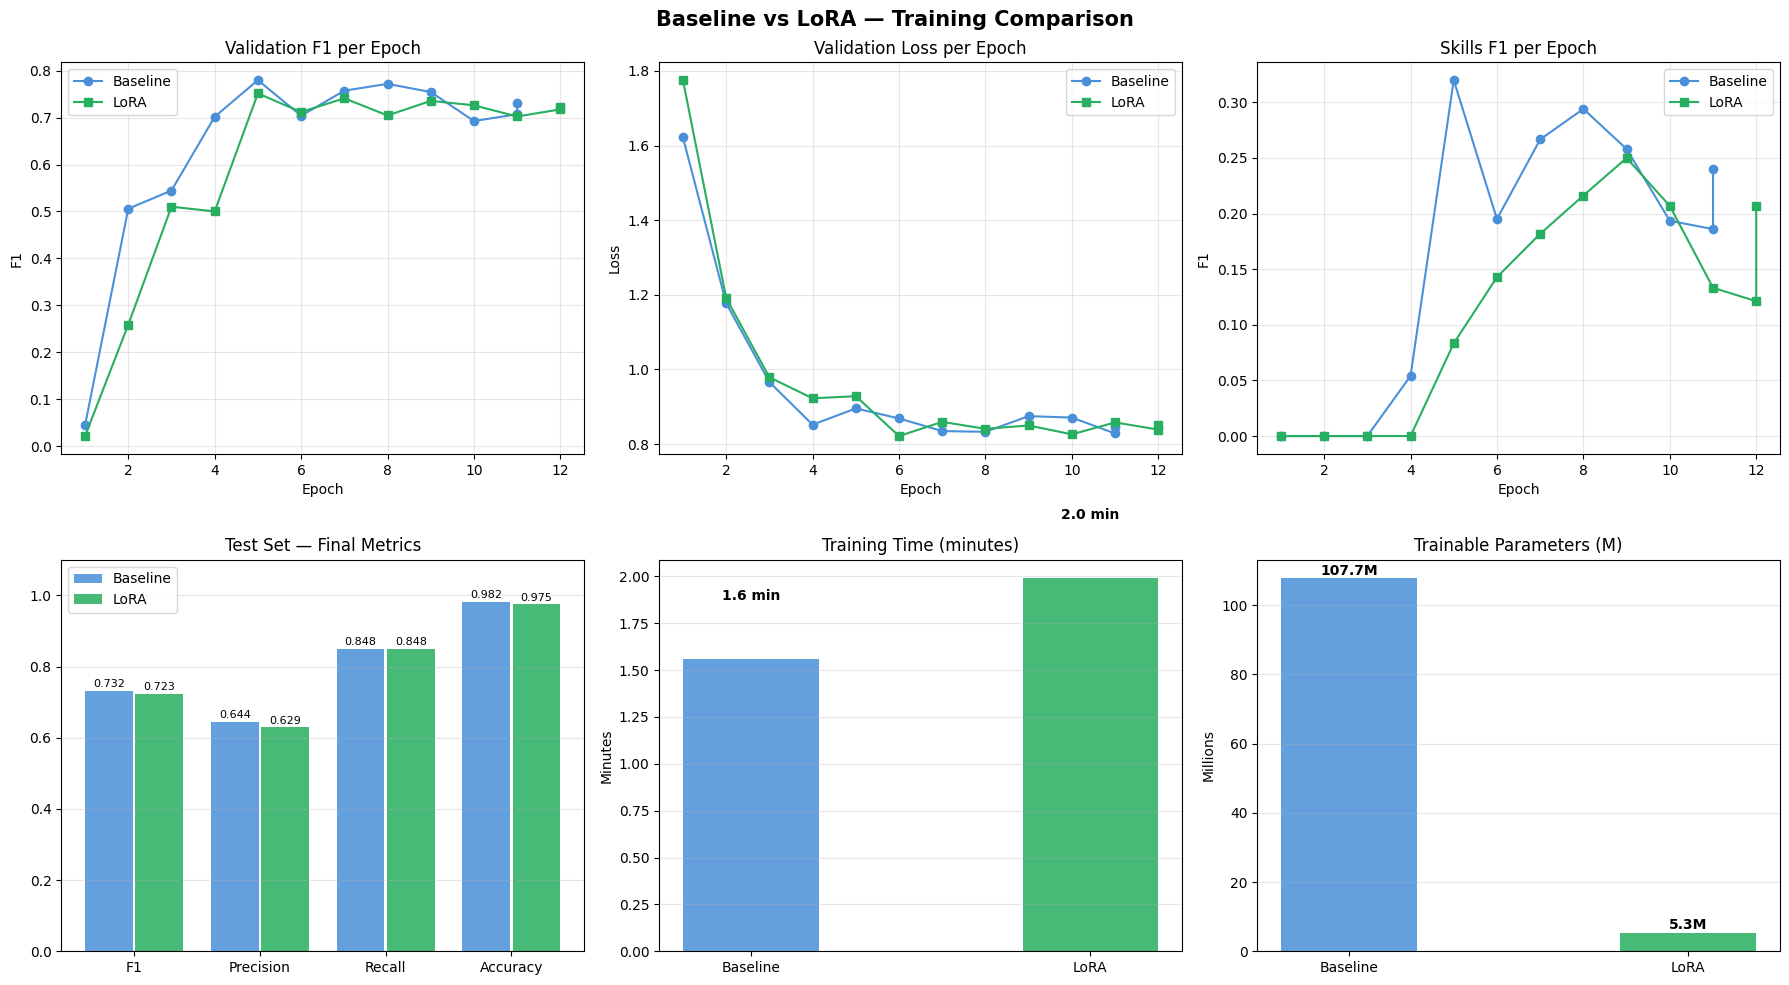

✅ Chart saved: comparison_baseline_vs_lora.png


In [ ]:
# Cell 17: Comparison Charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Baseline vs LoRA — Training Comparison', fontsize=15, fontweight='bold')

COLOR_BASE = '#4A90D9'
COLOR_LORA = '#27AE60'

# ── 1. Val F1 curve ──
ax = axes[0][0]
if hist_base['ep'] and hist_lora['ep']:
    ax.plot(hist_base['ep'], hist_base['vl_f1'], color=COLOR_BASE, marker='o', label='Baseline')
    ax.plot(hist_lora['ep'], hist_lora['vl_f1'], color=COLOR_LORA, marker='s', label='LoRA')
ax.set_title('Validation F1 per Epoch'); ax.set_xlabel('Epoch'); ax.set_ylabel('F1')
ax.legend(); ax.grid(alpha=0.3)

# ── 2. Val Loss curve ──
ax = axes[0][1]
if hist_base['vl_loss'] and hist_lora['vl_loss']:
    ax.plot(hist_base['ep'], hist_base['vl_loss'], color=COLOR_BASE, marker='o', label='Baseline')
    ax.plot(hist_lora['ep'], hist_lora['vl_loss'], color=COLOR_LORA, marker='s', label='LoRA')
ax.set_title('Validation Loss per Epoch'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── 3. Skills F1 curve ──
ax = axes[0][2]
if hist_base['vl_skills_f1'] and hist_lora['vl_skills_f1']:
    ax.plot(hist_base['ep'], hist_base['vl_skills_f1'], color=COLOR_BASE, marker='o', label='Baseline')
    ax.plot(hist_lora['ep'], hist_lora['vl_skills_f1'], color=COLOR_LORA, marker='s', label='LoRA')
ax.set_title('Skills F1 per Epoch'); ax.set_xlabel('Epoch'); ax.set_ylabel('F1')
ax.legend(); ax.grid(alpha=0.3)

# ── 4. Final metrics bar chart ──
ax = axes[1][0]
metrics_names = ['F1', 'Precision', 'Recall', 'Accuracy']
keys = ['eval_f1', 'eval_precision', 'eval_recall', 'eval_accuracy']
b_vals = [test_base.get(k, 0) for k in keys]
l_vals = [test_lora.get(k, 0) for k in keys]
x = np.arange(len(metrics_names))
bars_b = ax.bar(x - 0.2, b_vals, 0.38, label='Baseline', color=COLOR_BASE, alpha=0.85)
bars_l = ax.bar(x + 0.2, l_vals, 0.38, label='LoRA',     color=COLOR_LORA, alpha=0.85)
for bar in list(bars_b) + list(bars_l):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1); ax.set_title('Test Set — Final Metrics')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── 5. Training time ──
ax = axes[1][1]
times = [train_time_base/60, train_time_lora/60]
bars = ax.bar(['Baseline', 'LoRA'], times, color=[COLOR_BASE, COLOR_LORA], alpha=0.85, width=0.4)
for bar, val in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f} min', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Training Time (minutes)'); ax.set_ylabel('Minutes'); ax.grid(axis='y', alpha=0.3)

# ── 6. Trainable params ──
ax = axes[1][2]
_, b_tr = count_params(base_model_plain)
_, l_tr = count_params(lora_model)
params = [b_tr / 1e6, l_tr / 1e6]
bars = ax.bar(['Baseline', 'LoRA'], params, color=[COLOR_BASE, COLOR_LORA], alpha=0.85, width=0.4)
for bar, val in zip(bars, params):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Trainable Parameters (M)'); ax.set_ylabel('Millions'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_baseline_vs_lora.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Chart saved: comparison_baseline_vs_lora.png')


In [ ]:
# Cell 18: Save Comparison Results
_, b_tr = count_params(base_model_plain)
_, l_tr = count_params(lora_model)

results = {
    'timestamp': datetime.now().isoformat(),
    'dataset': DATA_PATH,
    'split': {'train': len(train_tokens), 'val': len(val_tokens), 'test': len(test_tokens)},
    'baseline': {
        'lr': LR_BASELINE,
        'trainable_params': b_tr,
        'train_time_min': round(train_time_base / 60, 2),
        'test_f1':        round(test_base.get('eval_f1', 0), 4),
        'test_precision': round(test_base.get('eval_precision', 0), 4),
        'test_recall':    round(test_base.get('eval_recall', 0), 4),
        'test_accuracy':  round(test_base.get('eval_accuracy', 0), 4),
        'best_val_f1':    round(best_f1_base[0], 4),
    },
    'lora': {
        'lr': LR_LORA,
        'r': LORA_R, 'alpha': LORA_ALPHA,
        'trainable_params': l_tr,
        'trainable_pct': round(l_tr / b_tr * 100, 2),
        'train_time_min': round(train_time_lora / 60, 2),
        'test_f1':        round(test_lora.get('eval_f1', 0), 4),
        'test_precision': round(test_lora.get('eval_precision', 0), 4),
        'test_recall':    round(test_lora.get('eval_recall', 0), 4),
        'test_accuracy':  round(test_lora.get('eval_accuracy', 0), 4),
        'best_val_f1':    round(best_f1_lora[0], 4),
    },
    'winner': {
        'f1':       'lora' if test_lora.get('eval_f1',0) > test_base.get('eval_f1',0) else 'baseline',
        'speed':    'lora' if train_time_lora < train_time_base else 'baseline',
        'params':   'lora',  # always
    }
}

with open('comparison_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('✅ Results saved: comparison_results.json')
print(json.dumps(results, indent=2))


✅ Results saved: comparison_results.json
{
  "timestamp": "2026-05-10T22:40:40.601979",
  "dataset": "Entity Recognition in Resumes.json",
  "split": {
    "train": 154,
    "val": 33,
    "test": 33
  },
  "baseline": {
    "lr": 2e-05,
    "trainable_params": 107725063,
    "train_time_min": 1.56,
    "test_f1": 0.732,
    "test_precision": 0.6437,
    "test_recall": 0.8485,
    "test_accuracy": 0.9815,
    "best_val_f1": 0.7647
  },
  "lora": {
    "lr": 0.0002,
    "r": 32,
    "alpha": 64,
    "trainable_params": 5313799,
    "trainable_pct": 4.93,
    "train_time_min": 1.99,
    "test_f1": 0.7226,
    "test_precision": 0.6292,
    "test_recall": 0.8485,
    "test_accuracy": 0.9746,
    "best_val_f1": 0.7201
  },
  "winner": {
    "f1": "baseline",
    "speed": "baseline",
    "params": "lora"
  }
}


---
## 🔍 Inference — اختبار الاتنين على نفس الـ CVs


In [ ]:
# Cell 19: Inference Engine (works for both models)
EMAIL_RE = re.compile(r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}')
PHONE_RE = re.compile(
    r'(?:\+?\d{1,3}[\s\-.]?\(?\d{2,4}\)?[\s\-.]?\d{3,4}[\s\-.]?\d{3,4}'
    r'|\b0\d{9,10}\b|\b\d{3}[\s\-.]\d{3}[\s\-.]\d{4}\b)'
)
NOISE_RE = re.compile(r'^[\s\-|,.:;()[\]{}\'"]+|[\s\-|,.:;()[\]{}\'"]+$')
_NOISE_TOK = {':',';','-','.','|','/','(',')','+','*','#','@','&'}

def tta_predict(model_obj, text):
    model_obj.eval()
    words = re.findall(r'\S+', text)
    if not words: return []
    acc = np.zeros((len(words), N_LABELS), dtype=np.float64)
    for run in range(TTA_RUNS + 1):
        if run > 0: model_obj.train()
        else:       model_obj.eval()
        for i in range(0, len(words), 128):
            chunk = words[i:i+128]
            enc   = tokenizer(chunk, is_split_into_words=True, return_tensors='pt',
                              truncation=True, max_length=MAX_LEN, padding=False)
            with torch.no_grad():
                logits = model_obj(**{k: v.to(DEVICE) for k,v in enc.items()}).logits[0]
            probs = torch.softmax(logits, -1).cpu().numpy()
            seen  = set()
            for ti, wid in enumerate(enc.word_ids(0)):
                if wid is None or wid in seen: continue
                seen.add(wid)
                gw = i + wid
                if gw < len(words): acc[gw] += probs[ti]
    acc /= (TTA_RUNS + 1)
    model_obj.eval()
    return [{'word': words[i], 'label': id2label[int(np.argmax(acc[i]))],
             'score': float(np.max(acc[i]))} for i in range(len(words))]

def skills_fallback(text, found):
    tl = text.lower(); fl = {s.lower() for s in found}; extra = []
    for sk in sorted(ALL_SKILLS_FLAT, key=len, reverse=True):
        skl = sk.lower()
        if skl in fl: continue
        if re.search(r'\b' + re.escape(skl) + r'\b', tl):
            extra.append(sk); fl.add(skl)
    return extra

def group_entities(preds, text, conf=INF_CONF):
    ents, cur_type, cur_words = {}, None, []
    def flush():
        if cur_type and cur_words:
            v = NOISE_RE.sub('', ' '.join(cur_words)).strip()
            if len(v) >= 2: ents.setdefault(cur_type, []).append(v)
    for wp in preds:
        lbl, sc, w = wp['label'], wp['score'], wp['word']
        if w in _NOISE_TOK: flush(); cur_type, cur_words = None, []; continue
        if lbl.startswith('B-') and sc >= conf:
            flush(); cur_type, cur_words = lbl[2:], [w]
        elif lbl.startswith('I-') and cur_type == lbl[2:] and sc >= conf * 0.75:
            cur_words.append(w)
        else: flush(); cur_type, cur_words = None, []
    flush()
    emails = list(dict.fromkeys(EMAIL_RE.findall(text)))
    if emails: ents['Email Address'] = emails
    phones = []
    for m in PHONE_RE.finditer(text):
        raw = m.group().strip(); digs = re.sub(r'[^\d]','',raw)
        if 8 <= len(digs) <= 15 and not re.fullmatch(r'(19|20)\d{2}',digs):
            phones.append(raw)
    if phones: ents['Phone'] = list(dict.fromkeys(phones))
    # Name cleanup
    if 'Name' in ents:
        names = [n for n in ents['Name']
                 if not EMAIL_RE.search(n) and not PHONE_RE.search(n) and len(n.split())>=1]
        ents['Name'] = [sorted(set(names), key=len)[0]] if names else []
    if not ents.get('Name'):
        for line in text.strip().split('\n')[:4]:
            line = line.strip()
            if EMAIL_RE.search(line) or PHONE_RE.search(line): continue
            if 2 <= len(line.split()) <= 5 and re.match(r'^[A-Za-z\s\-\']+$', line):
                ents['Name'] = [line]; break
    # Skills
    raw_sk = ents.get('Skills', [])
    expanded = []
    for sk in raw_sk:
        if ',' in sk:
            expanded.extend([p.strip().strip('-') for p in re.split(r'[,،]',sk) if len(p.strip())>=2])
        else: expanded.append(sk.strip('-').strip())
    expanded = [s for s in expanded if len(s)>=2
                and s.lower() not in {'skills','technical','soft','tools','skill'}]
    all_sk = list(dict.fromkeys(expanded + skills_fallback(text, expanded)))
    ents['Skills'] = all_sk if all_sk else []
    return {k: v for k, v in [
        ('Name', ents.get('Name',[])), ('Email Address', ents.get('Email Address',[])),
        ('Phone', ents.get('Phone',[])), ('Skills', ents.get('Skills',[]))
    ] if v}

print('✅ Inference engine loaded')


✅ Inference engine loaded


In [ ]:
# Cell 20: Side-by-Side Inference Test
TEST_CVS = [
    {'label': 'Data Analyst', 'text': (
        'Mohamed Hammad\nMohamedeeexx995@gmail.com | +201118319050 | Cairo, Egypt\n\n'
        'SKILLS\n- Python\n- SQL\n- Power BI\n- Tableau\n- Machine Learning\n- Pandas')},
    {'label': 'ML Engineer', 'text': (
        'Ahmed Ali\nahmad.ali@gmail.com | 01012345678 | Cairo\n\n'
        'SKILLS\n- TensorFlow\n- PyTorch\n- Python\n- Docker\n- AWS\n- NLP')},
    {'label': 'Software Engineer', 'text': (
        'Sara Hassan\nPhone: 00201234567890\n\n'
        'SKILLS\nJava, Spring Boot, React, PostgreSQL, Docker, Git, CI/CD')},
]

ORDER = ['Name', 'Email Address', 'Phone', 'Skills']

for cv in TEST_CVS:
    print(f"\n{'='*70}")
    print(f"  CV: {cv['label']}")
    print(f"{'='*70}")

    p_base = tta_predict(base_model_plain, cv['text'])
    p_lora = tta_predict(lora_model,       cv['text'])
    out_base = group_entities(p_base, cv['text'])
    out_lora = group_entities(p_lora, cv['text'])

    print(f"  {'Field':<22} {'🔵 BASELINE':<30} {'🟢 LORA'}")
    print(f"  {'-'*22} {'-'*30} {'-'*30}")
    for field in ORDER:
        b_val = ', '.join(out_base.get(field, ['⚠️ Not found']))
        l_val = ', '.join(out_lora.get(field, ['⚠️ Not found']))
        if field == 'Skills':
            b_val = f"{len(out_base.get(field,[]))} skills"
            l_val = f"{len(out_lora.get(field,[]))} skills"
        print(f"  {field:<22} {b_val[:28]:<30} {l_val[:28]}")



  CV: Data Analyst
  Field                  🔵 BASELINE                     🟢 LORA
  ---------------------- ------------------------------ ------------------------------
  Name                   Mohamed Hammad                 Mohamed Hammad
  Email Address          Mohamedeeexx995@gmail.com      Mohamedeeexx995@gmail.com
  Phone                  +201118319050                  +201118319050
  Skills                 6 skills                       6 skills

  CV: ML Engineer
  Field                  🔵 BASELINE                     🟢 LORA
  ---------------------- ------------------------------ ------------------------------
  Name                   Ahmed Ali                      Ahmed Ali
  Email Address          ahmad.ali@gmail.com            ahmad.ali@gmail.com
  Phone                  01012345678                    01012345678
  Skills                 7 skills                       6 skills

  CV: Software Engineer
  Field                  🔵 BASELINE                     🟢 LORA
  --------